In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Bases de datos**

In [2]:
import pandas as pd

# Data base 2025
df = pd.read_excel('/content/drive/MyDrive/Análisis restaurante/VENTAS_2025.xls', skiprows=3)
df['Fecha'] = pd.to_datetime(df['Cerrada']).dt.date
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = pd.to_datetime(df['Fecha']).dt.month
df['Dia'] = pd.to_datetime(df['Fecha']).dt.day
df['Dia_semana'] = pd.to_datetime(df['Cerrada']).dt.dayofweek
df['Hora'] = pd.to_datetime(df['Cerrada']).dt.hour
df = df[['Fecha', 'Mes', 'Dia', 'Dia_semana', 'Hora', 'Personas', 'Total']]
df = df[(df['Hora'] >= 8) & (df['Hora'] <= 21)]

df_25_q1 = df[df['Mes'].isin([1, 2, 3])]

# Data base 2026
df_26 = pd.read_excel('/content/drive/MyDrive/Análisis restaurante/VENTAS_ANUAL_2026.xls', skiprows=3)
df_26['Fecha'] = pd.to_datetime(df_26['Cerrada']).dt.date
df_26['Fecha'] = pd.to_datetime(df_26['Fecha'])
df_26['Mes'] = pd.to_datetime(df_26['Fecha']).dt.month
df_26['Dia'] = pd.to_datetime(df_26['Fecha']).dt.day
df_26['Dia_semana'] = pd.to_datetime(df_26['Cerrada']).dt.dayofweek
df_26['Hora'] = pd.to_datetime(df_26['Cerrada']).dt.hour
df_26 = df_26[['Fecha', 'Mes', 'Dia', 'Dia_semana', 'Hora', 'Personas', 'Total']]
df_26 = df_26[(df_26['Hora'] >= 8) & (df_26['Hora'] <= 21)]

In [3]:
df_26.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1570 entries, 1 to 1573
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Fecha       1570 non-null   datetime64[ns]
 1   Mes         1570 non-null   float64       
 2   Dia         1570 non-null   float64       
 3   Dia_semana  1570 non-null   float64       
 4   Hora        1570 non-null   float64       
 5   Personas    751 non-null    float64       
 6   Total       1570 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 98.1 KB


# **Análisis de ventas**

In [4]:
# Variables generales data base 2025
ventas_por_mes = df.groupby('Mes')['Total']
ventas_por_dia_mes = df.groupby('Dia')['Total']
ventas_por_dia = df.groupby('Dia_semana')['Total']
ventas_por_hora = df.groupby('Hora')['Total']

# Variables generales data base 2026
ventas_por_mes_26 = df_26.groupby('Mes')['Total']
ventas_por_dia_mes_26 = df_26.groupby('Dia')['Total']
ventas_por_dia_26 = df_26.groupby('Dia_semana')['Total']
ventas_por_hora_26 = df_26.groupby('Hora')['Total']

# Variables generales
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Sept.','Oct.','Nov.','Dic.']
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

## **Análisis de ventas 2025**

In [5]:
import plotly.graph_objects as go

conteo = ventas_por_mes.mean()

fig = go.Figure()

# Barras
fig.add_trace(go.Bar(
    x=meses, y=conteo.values,
    name='Cantidad de tickets',
    marker_color='#4361EE',
    marker_line_width=0,
    opacity=0.85
))

# Línea encima
fig.add_trace(go.Scatter(
    x=meses, y=conteo.values,
    name='Evolución mensual',
    mode='lines+markers',
    line=dict(color='#F72585', width=2.5, dash='dot'),
    marker=dict(size=7, color='#F72585')
))

fig.update_layout(
    title=dict(text='Cantidad de tickets mensuales en 2025',
               font=dict(size=18), x=0.02),
    template='plotly_white',
    legend=dict(orientation='h', y=1.08, x=0),
    plot_bgcolor='white',
    height=450,
    margin=dict(t=80, b=40, l=50, r=20),
    xaxis=dict(showgrid=False),
    yaxis=dict(gridcolor='#F0F0F0', gridwidth=1),
    bargap=0.35
)

fig.show()

In [6]:
conteo_26 = ventas_por_mes_26.mean()

fig = go.Figure()

# Barras
fig.add_trace(go.Bar(
    x=meses, y=conteo_26.values,
    name='Cantidad de tickets',
    marker_color='#4361EE',
    marker_line_width=0,
    opacity=0.85
))

# Línea encima
fig.add_trace(go.Scatter(
    x=meses, y=conteo_26.values,
    name='Evolución mensual',
    mode='lines+markers',
    line=dict(color='#F72585', width=2.5, dash='dot'),
    marker=dict(size=7, color='#F72585')
))

fig.update_layout(
    title=dict(text='Cantidad de tickets mensuales en 2026',
               font=dict(size=18), x=0.02),
    template='plotly_white',
    legend=dict(orientation='h', y=1.08, x=0),
    plot_bgcolor='white',
    height=450,
    margin=dict(t=80, b=40, l=50, r=20),
    xaxis=dict(showgrid=False),
    yaxis=dict(gridcolor='#F0F0F0', gridwidth=1),
    bargap=0.35
)

fig.show()

In [7]:
import plotly.graph_objects as go

# --- Definir aquí para no depender de otras celdas ---
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

mapa_dias = {0:'Lunes', 1:'Martes', 2:'Miercoles', 3:'Jueves',
             4:'Viernes', 5:'Sábado', 6:'Domingo'}

# Tabla pivote hora x dia
heatmap_data = (
    df.assign(Dia_nombre=df['Dia_semana'].map(mapa_dias))
      .groupby(['Hora', 'Dia_nombre'])['Total']
      .count()
      .unstack()
      .reindex(columns=dias_semana)
)

horas_label = [f'{h:02d}:00' for h in heatmap_data.index]

# --- Plotly ---
fig = go.Figure(go.Heatmap(
    z=heatmap_data.values,
    x=dias_semana,
    y=horas_label,
    colorscale='YlOrRd',
    text=heatmap_data.values,
    texttemplate='%{text:.0f}',
    textfont=dict(size=11),
    hoverongaps=False,
    hovertemplate='<b>%{x}</b><br>%{y}<br>Tickets: <b>%{z}</b><extra></extra>',
    colorbar=dict(
        title=dict(text='Tickets', side='right'),
        thickness=14,
        len=0.85
    )
))

fig.update_layout(
    title=dict(
        text='<b>Concentración de tickets por hora y día — 2025</b><br>'
             '<span style="font-size:12px;color:#888888">Cantidad de tickets vendidos por franja horaria</span>',
        font=dict(size=16, color='#1A1A2E'),
        x=0.02, xanchor='left'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    height=580,
    margin=dict(t=110, b=40, l=80, r=30),
    xaxis=dict(side='top', tickfont=dict(size=13), tickangle=0),
    yaxis=dict(autorange='reversed', tickfont=dict(size=11)),
)

fig.show()
fig.write_html('heatmap_tickets_2025.html')

In [8]:
import plotly.graph_objects as go

dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

mapa_dias = {0:'Lunes', 1:'Martes', 2:'Miercoles', 3:'Jueves',
             4:'Viernes', 5:'Sábado', 6:'Domingo'}

heatmap_data_26 = (
    df_26.assign(Dia_nombre=df_26['Dia_semana'].map(mapa_dias))
         .groupby(['Hora', 'Dia_nombre'])['Total']
         .count()
         .unstack()
         .reindex(columns=dias_semana)
)

horas_label = [f'{int(h):02d}:00' for h in heatmap_data_26.index]

fig = go.Figure(go.Heatmap(
    z=heatmap_data_26.values,
    x=dias_semana,
    y=horas_label,
    colorscale='YlOrRd',
    text=heatmap_data_26.values,
    texttemplate='%{text:.0f}',
    textfont=dict(size=11),
    hoverongaps=False,
    hovertemplate='<b>%{x}</b><br>%{y}<br>Tickets: <b>%{z}</b><extra></extra>',
    colorbar=dict(
        title=dict(text='Tickets', side='right'),
        thickness=14,
        len=0.85
    )
))

fig.update_layout(
    title=dict(
        text='<b>Concentración de tickets por hora y día — 2026</b><br>'
             '<span style="font-size:12px;color:#888888">Cantidad de tickets vendidos por franja horaria</span>',
        font=dict(size=16, color='#1A1A2E'),
        x=0.02, xanchor='left'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    height=580,
    margin=dict(t=110, b=40, l=80, r=30),
    xaxis=dict(side='top', tickfont=dict(size=13), tickangle=0),
    yaxis=dict(autorange='reversed', tickfont=dict(size=11)),
)

fig.show()
fig.write_html('heatmap_tickets_2026.html')

In [9]:
def heatmap_tickets(dataframe, año):
    dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    mapa_dias   = {0:'Lunes', 1:'Martes', 2:'Miercoles', 3:'Jueves',
                   4:'Viernes', 5:'Sábado', 6:'Domingo'}

    data = (
        dataframe.assign(Dia_nombre=dataframe['Dia_semana'].map(mapa_dias))
                 .groupby(['Hora', 'Dia_nombre'])['Total']
                 .count()
                 .unstack()
                 .reindex(columns=dias_semana)
    )

    fig = go.Figure(go.Heatmap(
        z=data.values,
        x=dias_semana,
        y=[f'{int(h):02d}:00' for h in data.index],
        colorscale='YlOrRd',
        text=data.values,
        texttemplate='%{text:.0f}',
        textfont=dict(size=11),
        hoverongaps=False,
        hovertemplate='<b>%{x}</b><br>%{y}<br>Tickets: <b>%{z}</b><extra></extra>',
        colorbar=dict(title=dict(text='Tickets', side='right'), thickness=14, len=0.85)
    ))

    fig.update_layout(
        title=dict(
            text=f'<b>Concentración de tickets por hora y día — {año}</b><br>'
                 f'<span style="font-size:12px;color:#888888">Cantidad de tickets vendidos por franja horaria</span>',
            font=dict(size=16, color='#1A1A2E'),
            x=0.02, xanchor='left'
        ),
        plot_bgcolor='#FFFFFF', paper_bgcolor='#FFFFFF',
        height=580, margin=dict(t=110, b=40, l=80, r=30),
        xaxis=dict(side='top', tickfont=dict(size=13), tickangle=0),
        yaxis=dict(autorange='reversed', tickfont=dict(size=11)),
    )

    fig.show()
    fig.write_html(f'heatmap_tickets_{año}.html')

# Usar así:
heatmap_tickets(df,    2025)
heatmap_tickets(df_26, 2026)

In [10]:
heatmap_tickets(df_25_q1, '2025 (Ene–Mar)')

In [11]:
heatmap_tickets(df_26,    '2026 (Ene–Mar)')

In [12]:
# Tickets y revenue actuales en las horas muertas
horas_noche = [18, 19, 20, 21]
dias_objetivo = [2, 5]  # 2=Miércoles, 5=Sábado

# --- 2025 completo ---
noche_25 = df[
    (df['Hora'].isin(horas_noche)) &
    (df['Dia_semana'].isin(dias_objetivo))
]

tickets_25  = len(noche_25)
revenue_25  = noche_25['Total'].sum()
promedio_25 = noche_25['Total'].mean()
noches_25   = df[df['Dia_semana'].isin(dias_objetivo)]['Fecha'].dt.isocalendar().week.nunique()

# --- 2026 Ene-Mar ---
noche_26 = df_26[
    (df_26['Hora'].isin(horas_noche)) &
    (df_26['Dia_semana'].isin(dias_objetivo))
]

tickets_26  = len(noche_26)
revenue_26  = noche_26['Total'].sum()
promedio_26 = noche_26['Total'].mean()

# --- Hora pico para comparar (15:00-16:00, todos los días) ---
pico_25 = df[df['Hora'].isin([15, 16])]
promedio_pico_25 = pico_25['Total'].mean()

# --- Proyección si aumentas 30% los tickets en esas noches ---
ticket_promedio = 260  # tu promedio actual

tickets_extra_30 = tickets_25 * 0.30
revenue_extra_30 = tickets_extra_30 * ticket_promedio

tickets_extra_50 = tickets_25 * 0.50
revenue_extra_50 = tickets_extra_50 * ticket_promedio

print('=' * 50)
print('MIÉRCOLES Y SÁBADO — 18:00 a 21:00')
print('=' * 50)
print(f'\n📊 2025 (año completo)')
print(f'   Tickets totales:      {tickets_25}')
print(f'   Revenue total:        ${revenue_25:,.0f}')
print(f'   Ticket promedio:      ${promedio_25:,.0f}')
print(f'\n📊 2026 (Ene–Mar)')
print(f'   Tickets totales:      {tickets_26}')
print(f'   Revenue total:        ${revenue_26:,.0f}')
print(f'   Ticket promedio:      ${promedio_26:,.0f}')
print(f'\n📈 Hora pico (15–16h) ticket promedio 2025: ${promedio_pico_25:,.0f}')
print(f'   Diferencia vs noche:  ${promedio_pico_25 - promedio_25:,.0f} más por ticket en hora pico')
print(f'\n💰 Proyección con promoción (base 2025)')
print(f'   +30% tickets → {tickets_extra_30:.0f} tickets extra → ${revenue_extra_30:,.0f} adicionales/año')
print(f'   +50% tickets → {tickets_extra_50:.0f} tickets extra → ${revenue_extra_50:,.0f} adicionales/año')
print('=' * 50)

MIÉRCOLES Y SÁBADO — 18:00 a 21:00

📊 2025 (año completo)
   Tickets totales:      422
   Revenue total:        $143,582
   Ticket promedio:      $340

📊 2026 (Ene–Mar)
   Tickets totales:      68
   Revenue total:        $16,594
   Ticket promedio:      $244

📈 Hora pico (15–16h) ticket promedio 2025: $219
   Diferencia vs noche:  $-121 más por ticket en hora pico

💰 Proyección con promoción (base 2025)
   +30% tickets → 127 tickets extra → $32,916 adicionales/año
   +50% tickets → 211 tickets extra → $54,860 adicionales/año


In [13]:
import pandas as pd
import numpy as np

# ── ANÁLISIS COMPLETO POR HORA Y DÍA ──────────────────────────────────────

mapa_dias = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves',
             4:'Viernes', 5:'Sábado', 6:'Domingo'}

# Ticket promedio por hora y día (2025 completo)
pivot_revenue = (
    df.assign(Dia_nombre=df['Dia_semana'].map(mapa_dias))
      .groupby(['Hora', 'Dia_nombre'])['Total']
      .agg(['mean', 'count', 'sum'])
      .unstack()
)

# Franjas horarias
df['Franja'] = pd.cut(df['Hora'],
    bins=[7, 11, 14, 17, 21],
    labels=['Desayuno (8-11)', 'Comida (12-14)', 'Tarde (15-17)', 'Noche (18-21)'])

resumen_franja = df.groupby('Franja', observed=True)['Total'].agg(
    Tickets='count',
    Revenue_total='sum',
    Ticket_promedio='mean',
    Revenue_por_hora='sum'
).reset_index()

resumen_franja['% del revenue'] = (resumen_franja['Revenue_total'] /
                                    resumen_franja['Revenue_total'].sum() * 100).round(1)
resumen_franja['Ticket_promedio'] = resumen_franja['Ticket_promedio'].round(0)

# Por día de semana
resumen_dia = (
    df.assign(Dia_nombre=df['Dia_semana'].map(mapa_dias))
      .groupby('Dia_nombre')['Total']
      .agg(Tickets='count', Revenue='sum', Ticket_prom='mean')
      .reindex(['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'])
)
resumen_dia['Ticket_prom'] = resumen_dia['Ticket_prom'].round(0)

# Horas muertas vs horas pico
por_hora = df.groupby('Hora')['Total'].agg(['count','sum','mean']).round(0)
hora_pico = por_hora['count'].idxmax()
hora_muerta = por_hora['count'].idxmin()

# Revenue perdido en horas muertas vs pico
revenue_hora_pico = por_hora.loc[hora_pico, 'sum']
revenue_hora_muerta = por_hora.loc[hora_muerta, 'sum']
diferencia = revenue_hora_pico - revenue_hora_muerta

print('=' * 55)
print('ANÁLISIS DE RENDIMIENTO — RESTAURANTE 2025')
print('=' * 55)

print('\n📊 REVENUE POR FRANJA HORARIA')
print('-' * 55)
print(resumen_franja[['Franja','Tickets','Ticket_promedio','Revenue_total','% del revenue']].to_string(index=False))

print('\n📊 RENDIMIENTO POR DÍA DE SEMANA')
print('-' * 55)
print(resumen_dia.to_string())

print('\n📊 RENDIMIENTO POR HORA')
print('-' * 55)
print(por_hora.rename(columns={'count':'Tickets','sum':'Revenue','mean':'Ticket_prom'}).to_string())

print(f'\n⚡ Hora pico:   {hora_pico}:00h — {por_hora.loc[hora_pico,"count"]:.0f} tickets')
print(f'💀 Hora muerta: {hora_muerta}:00h — {por_hora.loc[hora_muerta,"count"]:.0f} tickets')
print(f'💰 Diferencia de revenue pico vs muerta: ${diferencia:,.0f}')
print('=' * 55)

ANÁLISIS DE RENDIMIENTO — RESTAURANTE 2025

📊 REVENUE POR FRANJA HORARIA
-------------------------------------------------------
         Franja  Tickets  Ticket_promedio  Revenue_total  % del revenue
Desayuno (8-11)     2266            223.0      504633.72           27.4
 Comida (12-14)     2017            211.0      425656.37           23.1
  Tarde (15-17)     2310            219.0      507042.40           27.5
  Noche (18-21)     1483            273.0      405194.03           22.0

📊 RENDIMIENTO POR DÍA DE SEMANA
-------------------------------------------------------
            Tickets    Revenue  Ticket_prom
Dia_nombre                                 
Lunes          1180  248486.18        211.0
Martes         1067  218207.57        205.0
Miércoles      1082  227312.62        210.0
Jueves         1052  210047.01        200.0
Viernes        1192  271889.28        228.0
Sábado         1178  317302.36        269.0
Domingo        1325  349281.50        264.0

📊 RENDIMIENTO POR HORA
--

In [14]:
import pandas as pd
import numpy as np

# Filtrar 2025 al mismo período que 2026 (ene-mar)
df_25_q1 = df[df['Mes'].isin([1, 2, 3])]

mapa_dias = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves',
             4:'Viernes', 5:'Sábado', 6:'Domingo'}

# ── COMPARATIVA GENERAL ───────────────────────────────────────
def resumen(d, label):
    return {
        'Periodo': label,
        'Tickets': len(d),
        'Revenue': d['Total'].sum(),
        'Ticket_prom': d['Total'].mean(),
        'Revenue_dia': d['Total'].sum() / d['Fecha'].nunique(),
        'Tickets_dia': len(d) / d['Fecha'].nunique(),
    }

r25 = resumen(df_25_q1, '2025 Ene-Mar')
r26 = resumen(df_26,    '2026 Ene-Mar')

print('=' * 58)
print('COMPARATIVA ENE-MAR: 2025 vs 2026')
print('=' * 58)
for k in ['Tickets','Revenue','Ticket_prom','Revenue_dia','Tickets_dia']:
    v25 = r25[k]
    v26 = r26[k]
    diff = ((v26 - v25) / v25) * 100
    signo = '+' if diff > 0 else ''
    print(f'{k:<20} 2025: {v25:>8.0f}   2026: {v26:>8.0f}   {signo}{diff:.1f}%')

# ── POR FRANJA HORARIA ────────────────────────────────────────
print('\n' + '=' * 58)
print('TICKETS POR FRANJA — cambio % ene-mar')
print('=' * 58)

for df_, label in [(df_25_q1, '2025'), (df_26, '2026')]:
    df_['Franja'] = pd.cut(df_['Hora'],
        bins=[7,11,14,17,21],
        labels=['Desayuno 8-11','Comida 12-14','Tarde 15-17','Noche 18-21'])

f25 = df_25_q1.groupby('Franja', observed=True)['Total'].agg(['count','sum','mean'])
f26 = df_26.groupby('Franja', observed=True)['Total'].agg(['count','sum','mean'])

for franja in f25.index:
    t25, t26 = f25.loc[franja,'count'], f26.loc[franja,'count']
    r25f, r26f = f25.loc[franja,'sum'], f26.loc[franja,'sum']
    dt = ((t26-t25)/t25)*100
    dr = ((r26f-r25f)/r25f)*100
    print(f'{str(franja):<18} tickets: {t25:>5.0f}→{t26:>5.0f} ({dt:+.1f}%)   revenue: ${r25f:>8.0f}→${r26f:>8.0f} ({dr:+.1f}%)')

# ── POR DÍA DE SEMANA ─────────────────────────────────────────
print('\n' + '=' * 58)
print('TICKETS POR DÍA — cambio % ene-mar')
print('=' * 58)

d25 = df_25_q1.assign(Dia=df_25_q1['Dia_semana'].map(mapa_dias)).groupby('Dia')['Total'].agg(['count','mean']).reindex(['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'])
d26 = df_26.assign(Dia=df_26['Dia_semana'].map(mapa_dias)).groupby('Dia')['Total'].agg(['count','mean']).reindex(['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'])

for dia in d25.index:
    t25, t26 = d25.loc[dia,'count'], d26.loc[dia,'count']
    p25, p26 = d25.loc[dia,'mean'], d26.loc[dia,'mean']
    dt = ((t26-t25)/t25)*100
    dp = ((p26-p25)/p25)*100
    print(f'{dia:<12} tickets: {t25:>5.0f}→{t26:>5.0f} ({dt:+.1f}%)   ticket prom: ${p25:>5.0f}→${p26:>5.0f} ({dp:+.1f}%)')

# ── POR MES ───────────────────────────────────────────────────
print('\n' + '=' * 58)
print('EVOLUCIÓN MENSUAL — tickets y revenue')
print('=' * 58)
meses_label = {1:'Enero', 2:'Febrero', 3:'Marzo'}
for m in [1, 2, 3]:
    t25 = len(df_25_q1[df_25_q1['Mes']==m])
    t26 = len(df_26[df_26['Mes']==m])
    r25m = df_25_q1[df_25_q1['Mes']==m]['Total'].sum()
    r26m = df_26[df_26['Mes']==m]['Total'].sum()
    dt = ((t26-t25)/t25)*100
    dr = ((r26m-r25m)/r25m)*100
    print(f'{meses_label[m]:<10} tickets: {t25:>4}→{t26:>4} ({dt:+.1f}%)   revenue: ${r25m:>8.0f}→${r26m:>8.0f} ({dr:+.1f}%)')

print('=' * 58)

COMPARATIVA ENE-MAR: 2025 vs 2026
Tickets              2025:     1761   2026:     1570   -10.8%
Revenue              2025:   385204   2026:   347144   -9.9%
Ticket_prom          2025:      219   2026:      221   +1.1%
Revenue_dia          2025:     4233   2026:     4394   +3.8%
Tickets_dia          2025:       19   2026:       20   +2.7%

TICKETS POR FRANJA — cambio % ene-mar
Desayuno 8-11      tickets:   562→  430 (-23.5%)   revenue: $  131249→$   88453 (-32.6%)
Comida 12-14       tickets:   475→  365 (-23.2%)   revenue: $   93234→$   75532 (-19.0%)
Tarde 15-17        tickets:   521→  448 (-14.0%)   revenue: $  108419→$   99087 (-8.6%)
Noche 18-21        tickets:   203→  327 (+61.1%)   revenue: $   52302→$   84072 (+60.7%)

TICKETS POR DÍA — cambio % ene-mar
Lunes        tickets:   257→  231 (-10.1%)   ticket prom: $  198→$  215 (+8.4%)
Martes       tickets:   230→  189 (-17.8%)   ticket prom: $  181→$  200 (+10.2%)
Miércoles    tickets:   247→  188 (-23.9%)   ticket prom: $  199→$  1

/tmp/ipykernel_10584/3839058572.py:40: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



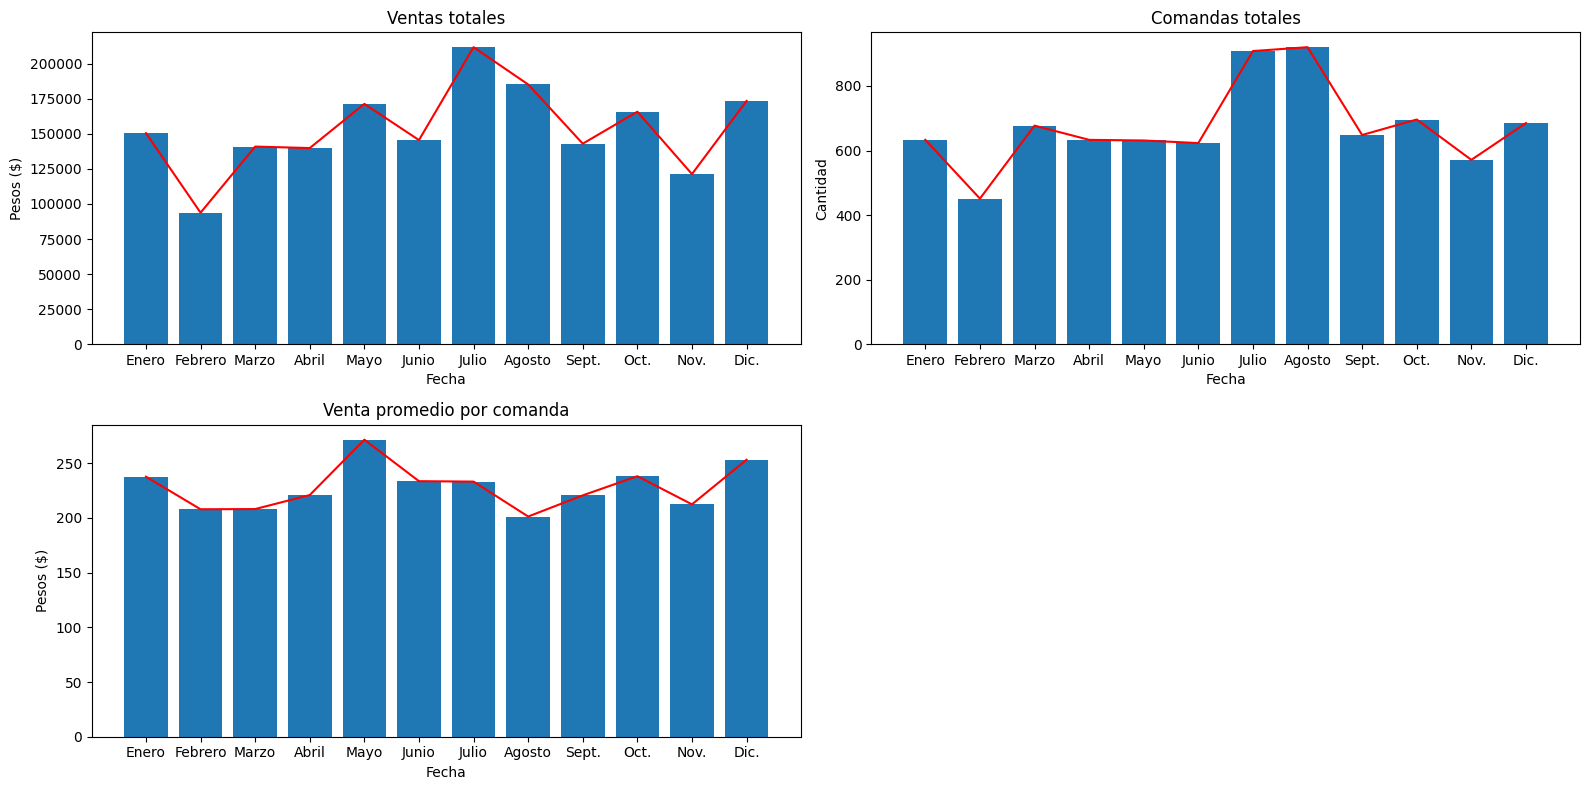

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


ventas_por_mes = df.groupby('Mes')['Total']

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.title('Ventas totales')
plt.bar(ventas_por_mes.sum().index, ventas_por_mes.sum().values)
plt.plot(ventas_por_mes.sum().index, ventas_por_mes.sum().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Sept.', 'Oct.', 'Nov.', 'Dic.'])


plt.subplot(2, 2, 2)
plt.title('Comandas totales')
plt.bar(ventas_por_mes.count().index, ventas_por_mes.count().values)
plt.plot(ventas_por_mes.count().index, ventas_por_mes.count().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Sept.', 'Oct.', 'Nov.', 'Dic.'])


plt.subplot(2, 2, 3)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_mes.mean().index, ventas_por_mes.mean().values)
plt.plot(ventas_por_mes.mean().index, ventas_por_mes.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Sept.', 'Oct.', 'Nov.', 'Dic.'])

plt.tight_layout()
plt.show()

In [16]:
import plotly.graph_objects as go
import plotly.io as pio

conteo = ventas_por_mes.count()
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

# Colores de tu marca (cámbialos por los del cliente)
COLOR_BARRA  = '#4361EE'
COLOR_LINEA  = '#F72585'
COLOR_FONDO  = '#FFFFFF'
COLOR_GRID   = '#F0F0F0'
COLOR_TITULO = '#1A1A2E'

fig = go.Figure()

# Barras
fig.add_trace(go.Bar(
    x=meses,
    y=conteo.values,
    name='Tickets',
    marker=dict(color=COLOR_BARRA, opacity=0.85, line=dict(width=0)),
    text=conteo.values,         # etiquetas encima
    textposition='outside',
    textfont=dict(size=11, color='#555555'),
))

# Línea de tendencia
fig.add_trace(go.Scatter(
    x=meses,
    y=conteo.values,
    name='Evolución',
    mode='lines+markers',
    line=dict(color=COLOR_LINEA, width=2.5, dash='dot'),
    marker=dict(size=8, color=COLOR_LINEA,
                line=dict(color='white', width=2)),  # marker con borde blanco
))

fig.update_layout(
    # Título y subtítulo
    title=dict(
        text='<b>Tickets mensuales 2025</b><br>'
             '<span style="font-size:13px;color:#888">Volumen total de ventas por mes</span>',
        font=dict(size=20, color=COLOR_TITULO),
        x=0.02, xanchor='left'
    ),

    # Fondo y bordes
    plot_bgcolor=COLOR_FONDO,
    paper_bgcolor=COLOR_FONDO,

    # Ejes
    xaxis=dict(
        showgrid=False,
        showline=True,
        linecolor='#DDDDDD',
        tickfont=dict(size=12, color='#555555'),
    ),
    yaxis=dict(
        gridcolor=COLOR_GRID,
        gridwidth=1,
        showline=False,
        tickfont=dict(size=11, color='#999999'),
        title=None,
    ),

    # Leyenda horizontal arriba
    legend=dict(
        orientation='h',
        y=1.12, x=0,
        font=dict(size=12),
        bgcolor='rgba(0,0,0,0)'
    ),

    # Espaciado
    bargap=0.38,
    height=480,
    margin=dict(t=100, b=50, l=40, r=30),
)

# --- Exportar

In [17]:
pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.0 MB/s eta 0:00:00


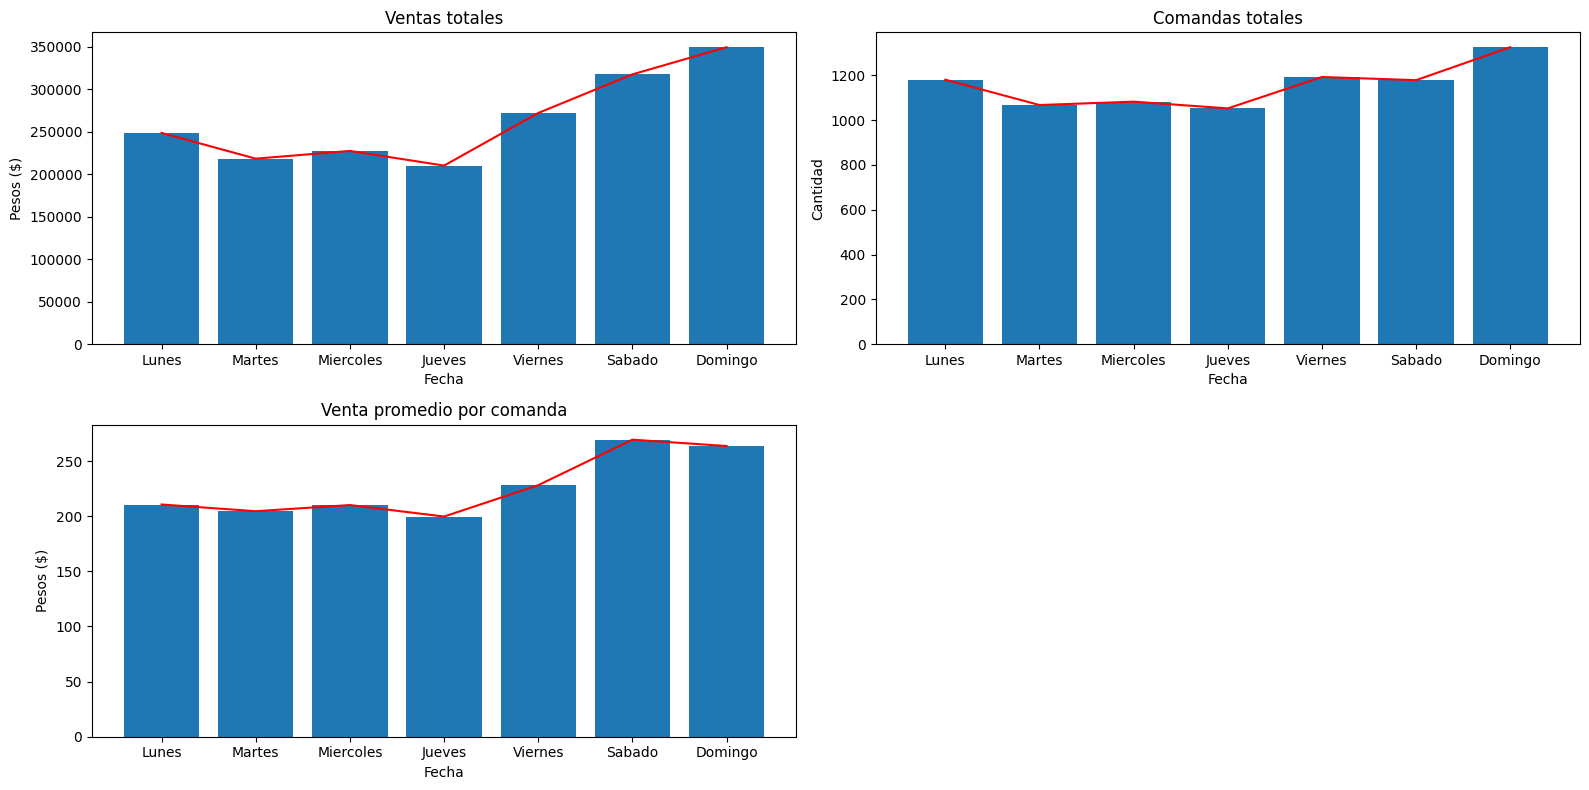

In [18]:
ventas_por_dia = df.groupby('Dia_semana')['Total']

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.title('Ventas totales')
plt.bar(ventas_por_dia.sum().index, ventas_por_dia.sum().values)
plt.plot(ventas_por_dia.sum().index, ventas_por_dia.sum().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

plt.subplot(2, 2, 2)
plt.title('Comandas totales')
plt.bar(ventas_por_dia.count().index, ventas_por_dia.count().values)
plt.plot(ventas_por_dia.count().index, ventas_por_dia.count().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

plt.subplot(2, 2, 3)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_dia.mean().index, ventas_por_dia.mean().values)
plt.plot(ventas_por_dia.mean().index, ventas_por_dia.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

plt.tight_layout()
plt.show()

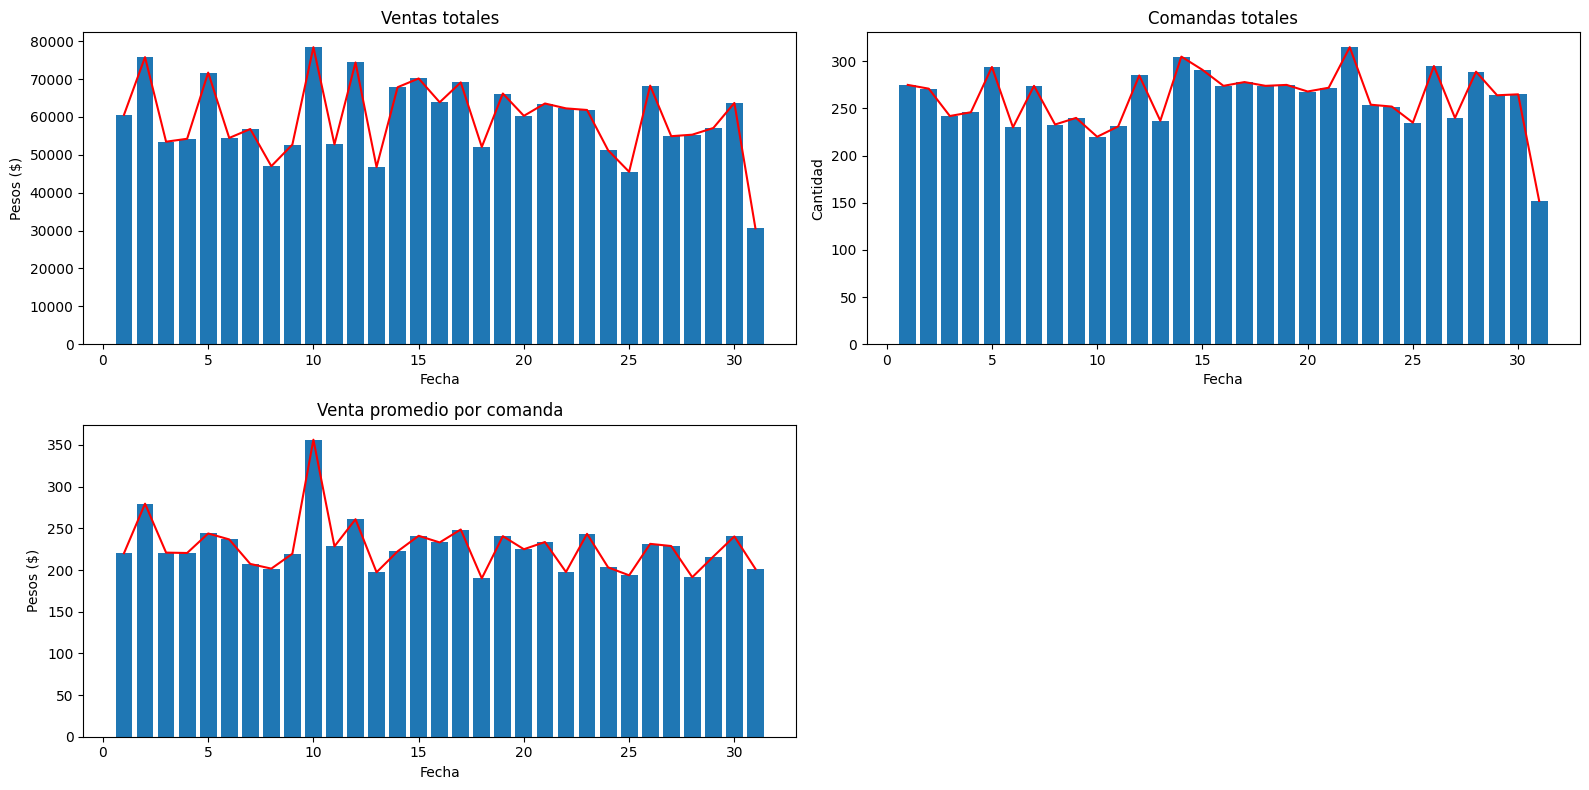

In [19]:
ventas_por_dia_mes = df.groupby('Dia')['Total']

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.title('Ventas totales')
plt.bar(ventas_por_dia_mes.sum().index, ventas_por_dia_mes.sum().values)
plt.plot(ventas_por_dia_mes.sum().index, ventas_por_dia_mes.sum().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')

plt.subplot(2, 2, 2)
plt.title('Comandas totales')
plt.bar(ventas_por_dia_mes.count().index, ventas_por_dia_mes.count().values)
plt.plot(ventas_por_dia_mes.count().index, ventas_por_dia_mes.count().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')

plt.subplot(2, 2, 3)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_dia_mes.mean().index, ventas_por_dia_mes.mean().values)
plt.plot(ventas_por_dia_mes.mean().index, ventas_por_dia_mes.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')

plt.tight_layout()
plt.show()

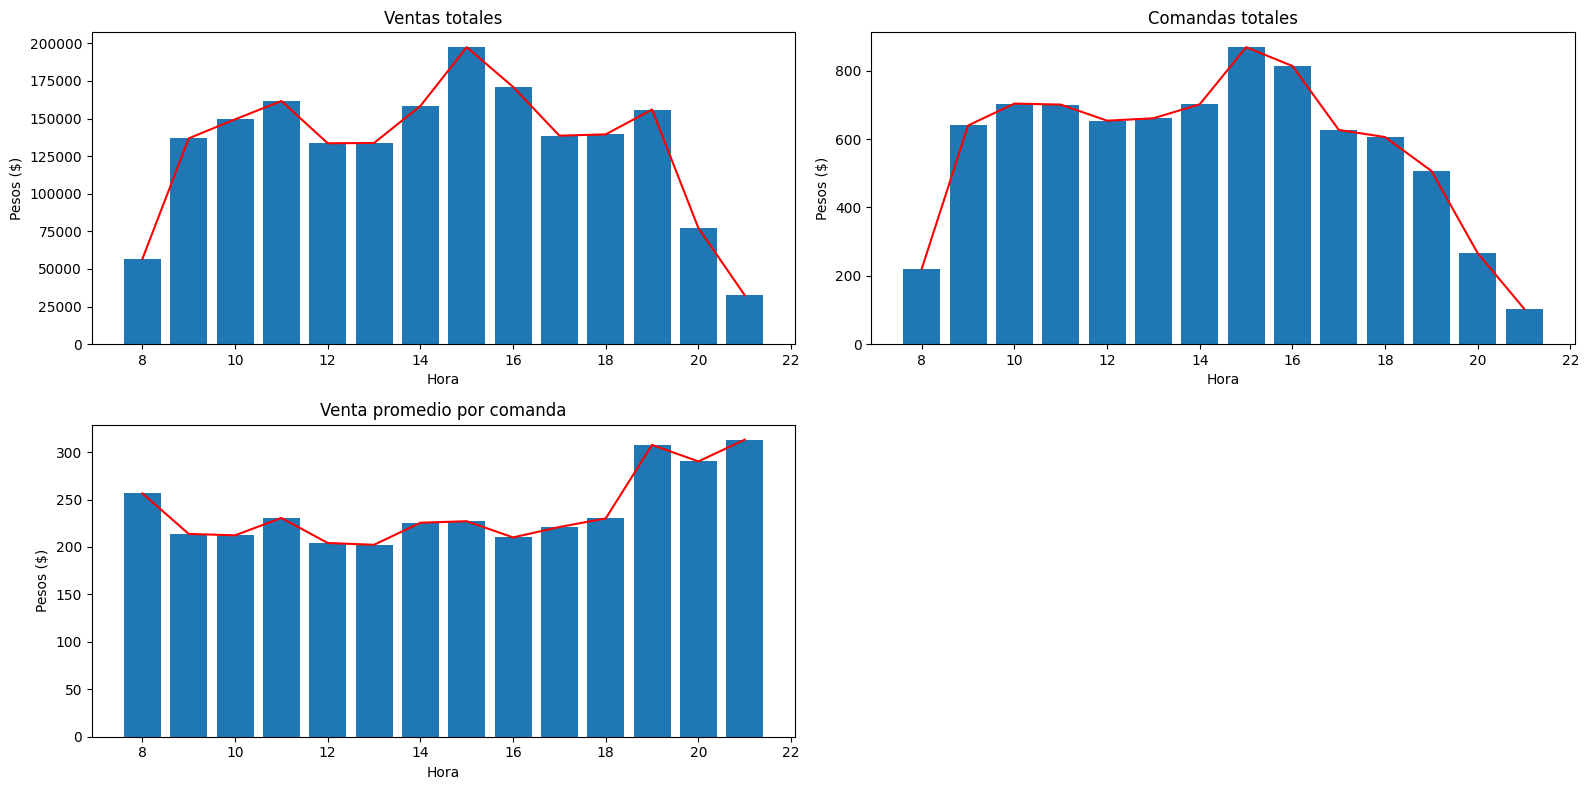

In [20]:
ventas_por_hora = df.groupby('Hora')['Total']

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.title('Ventas totales')
plt.bar(ventas_por_hora.sum().index, ventas_por_hora.sum().values)
plt.plot(ventas_por_hora.sum().index, ventas_por_hora.sum().values, color='red')
plt.xlabel('Hora')
plt.ylabel('Pesos ($)')

plt.subplot(2, 2, 2)
plt.title('Comandas totales')
plt.bar(ventas_por_hora.count().index, ventas_por_hora.count().values)
plt.plot(ventas_por_hora.count().index, ventas_por_hora.count().values, color='red')
plt.xlabel('Hora')
plt.ylabel('Pesos ($)')

plt.subplot(2, 2, 3)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_hora.mean().index, ventas_por_hora.mean().values)
plt.plot(ventas_por_hora.mean().index, ventas_por_hora.mean().values, color='red')
plt.xlabel('Hora')
plt.ylabel('Pesos ($)')



plt.tight_layout()
plt.show()

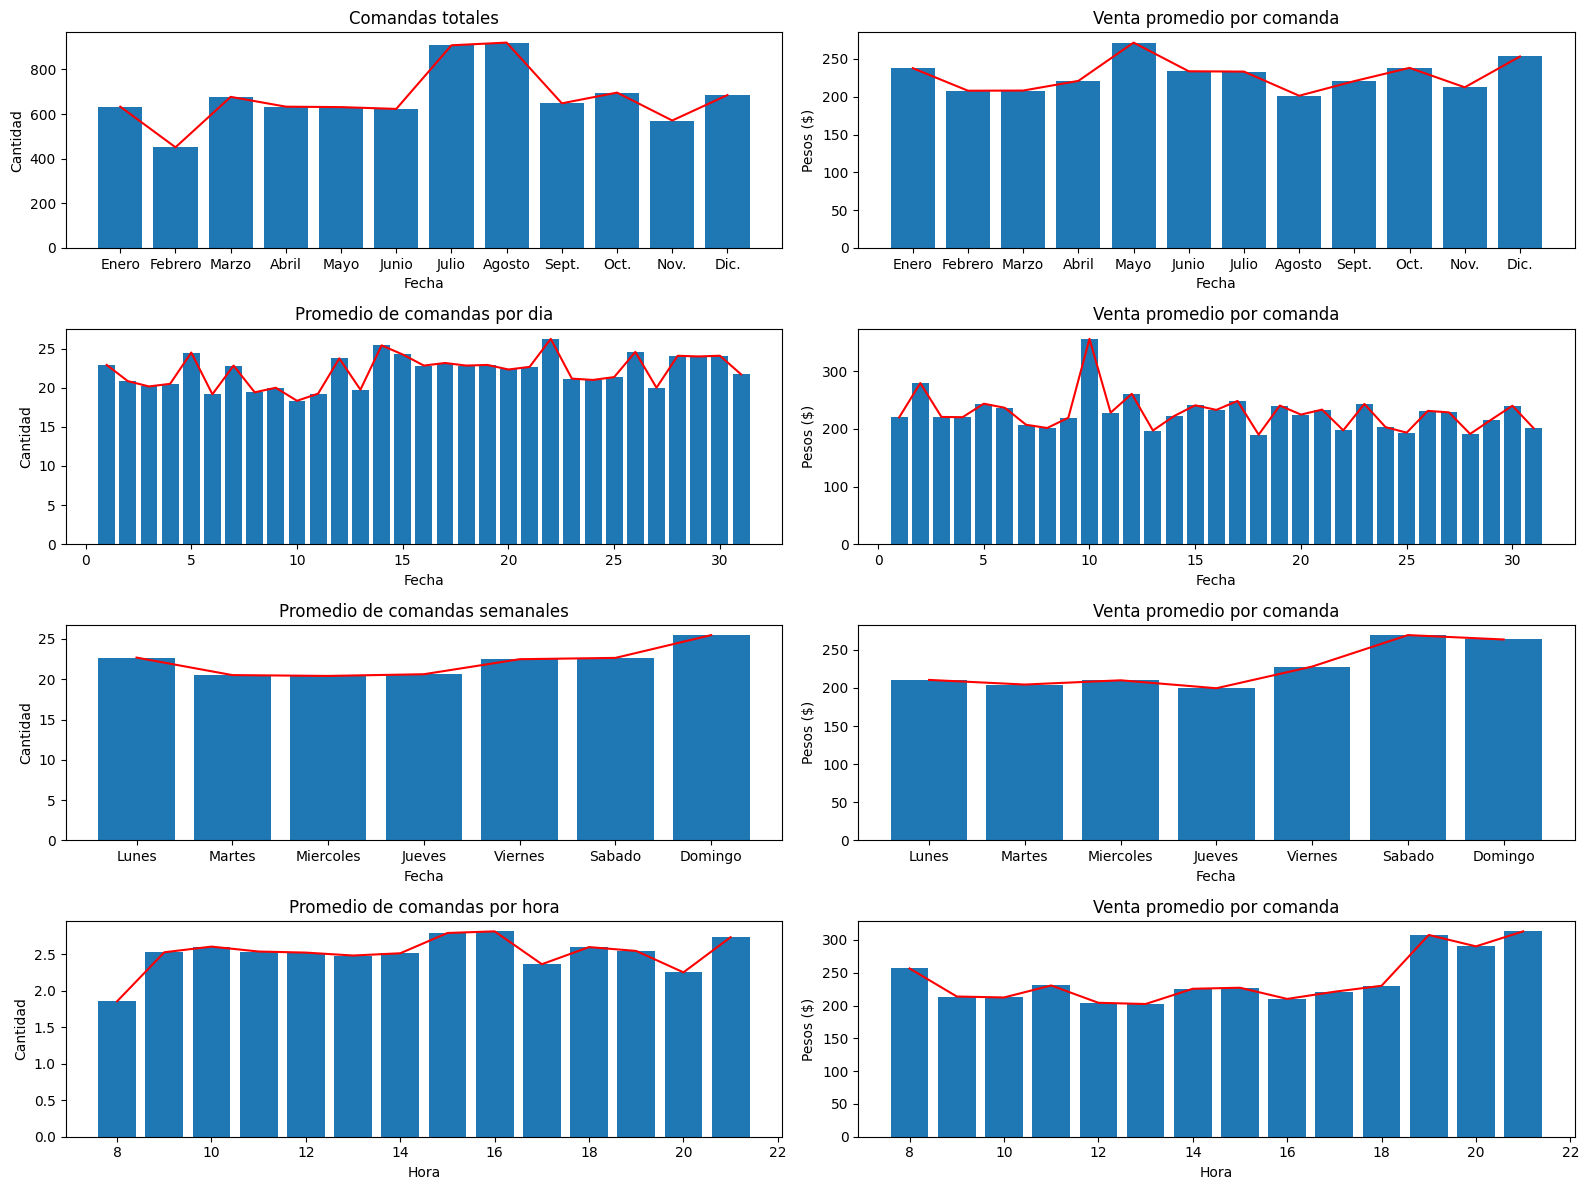

In [21]:
plt.figure(figsize=(16, 12))

# Mensual
plt.subplot(4, 2, 1)
plt.title('Comandas totales')
plt.bar(ventas_por_mes.count().index, ventas_por_mes.count().values)
plt.plot(ventas_por_mes.count().index, ventas_por_mes.count().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Sept.', 'Oct.', 'Nov.', 'Dic.'])

plt.subplot(4, 2, 2)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_mes.mean().index, ventas_por_mes.mean().values)
plt.plot(ventas_por_mes.mean().index, ventas_por_mes.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Sept.', 'Oct.', 'Nov.', 'Dic.'])

# Diario
plt.subplot(4, 2, 3)
plt.title('Promedio de comandas por dia')
plt.bar(ventas_por_dia_mes.count().index, ventas_por_dia_mes.count()/df.groupby('Dia')['Fecha'].nunique())
plt.plot(ventas_por_dia_mes.count().index, ventas_por_dia_mes.count().values/df.groupby('Dia')['Fecha'].nunique(), color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')

plt.subplot(4, 2, 4)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_dia_mes.mean().index, ventas_por_dia_mes.mean().values)
plt.plot(ventas_por_dia_mes.mean().index, ventas_por_dia_mes.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')

# Semanal
plt.subplot(4, 2, 5)
plt.title('Promedio de comandas semanales')
plt.bar(ventas_por_dia.count().index, ventas_por_dia.count()/df.groupby('Dia_semana')['Fecha'].nunique())
plt.plot(ventas_por_dia.count().index, ventas_por_dia.count().values/df.groupby('Dia_semana')['Fecha'].nunique(), color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

plt.subplot(4, 2, 6)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_dia.mean().index, ventas_por_dia.mean().values)
plt.plot(ventas_por_dia.mean().index, ventas_por_dia.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

# Por hora
plt.subplot(4, 2, 7)
plt.title('Promedio de comandas por hora')
plt.bar(ventas_por_hora.count().index, ventas_por_hora.count().values/df.groupby('Hora')['Fecha'].nunique())
plt.plot(ventas_por_hora.count().index, ventas_por_hora.count().values/df.groupby('Hora')['Fecha'].nunique(), color='red')
plt.xlabel('Hora')
plt.ylabel('Cantidad')

plt.subplot(4, 2, 8)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_hora.mean().index, ventas_por_hora.mean().values)
plt.plot(ventas_por_hora.mean().index, ventas_por_hora.mean().values, color='red')
plt.xlabel('Hora')
plt.ylabel('Pesos ($)')

plt.tight_layout()
plt.show()

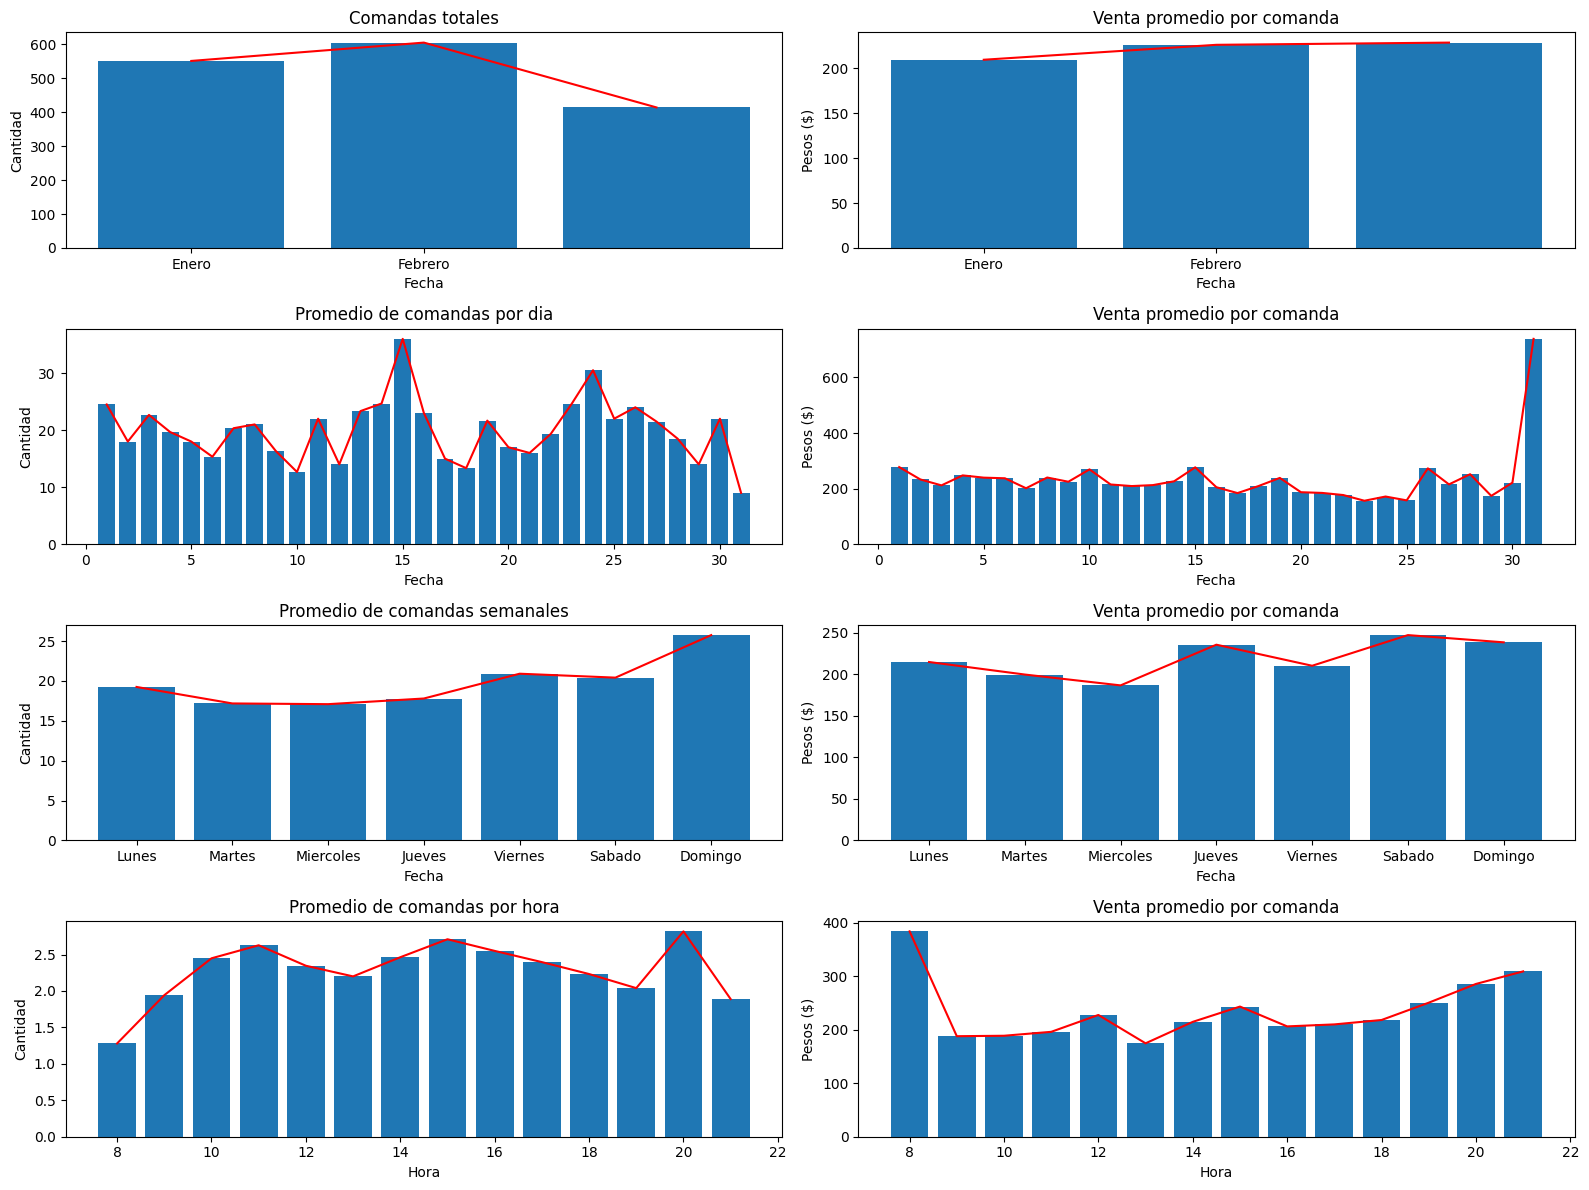

In [22]:
ventas_por_mes_26 = df_26.groupby('Mes')['Total']
ventas_por_dia_mes_26 = df_26.groupby('Dia')['Total']
ventas_por_dia_26 = df_26.groupby('Dia_semana')['Total']
ventas_por_hora_26 = df_26.groupby('Hora')['Total']

plt.figure(figsize=(16, 12))

# Mensual
plt.subplot(4, 2, 1)
plt.title('Comandas totales')
plt.bar(ventas_por_mes_26.count().index, ventas_por_mes_26.count().values)
plt.plot(ventas_por_mes_26.count().index, ventas_por_mes_26.count().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.xticks([1, 2],
 ['Enero', 'Febrero'])

plt.subplot(4, 2, 2)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_mes_26.mean().index, ventas_por_mes_26.mean().values)
plt.plot(ventas_por_mes_26.mean().index, ventas_por_mes_26.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([1, 2],
 ['Enero', 'Febrero'])

# Diario
plt.subplot(4, 2, 3)
plt.title('Promedio de comandas por dia')
plt.bar(ventas_por_dia_mes_26.count().index, ventas_por_dia_mes_26.count()/df_26.groupby('Dia')['Fecha'].nunique())
plt.plot(ventas_por_dia_mes_26.count().index, ventas_por_dia_mes_26.count().values/df_26.groupby('Dia')['Fecha'].nunique(), color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')

plt.subplot(4, 2, 4)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_dia_mes_26.mean().index, ventas_por_dia_mes_26.mean().values)
plt.plot(ventas_por_dia_mes_26.mean().index, ventas_por_dia_mes_26.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')

# Semanal
plt.subplot(4, 2, 5)
plt.title('Promedio de comandas semanales')
plt.bar(ventas_por_dia_26.count().index, ventas_por_dia_26.count()/df_26.groupby('Dia_semana')['Fecha'].nunique())
plt.plot(ventas_por_dia_26.count().index, ventas_por_dia_26.count().values/df_26.groupby('Dia_semana')['Fecha'].nunique(), color='red')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

plt.subplot(4, 2, 6)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_dia_26.mean().index, ventas_por_dia_26.mean().values)
plt.plot(ventas_por_dia_26.mean().index, ventas_por_dia_26.mean().values, color='red')
plt.xlabel('Fecha')
plt.ylabel('Pesos ($)')
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

# Por hora
plt.subplot(4, 2, 7)
plt.title('Promedio de comandas por hora')
plt.bar(ventas_por_hora_26.count().index, ventas_por_hora_26.count().values/df_26.groupby('Hora')['Fecha'].nunique())
plt.plot(ventas_por_hora_26.count().index, ventas_por_hora_26.count().values/df_26.groupby('Hora')['Fecha'].nunique(), color='red')
plt.xlabel('Hora')
plt.ylabel('Cantidad')

plt.subplot(4, 2, 8)
plt.title('Venta promedio por comanda')
plt.bar(ventas_por_hora_26.mean().index, ventas_por_hora_26.mean().values)
plt.plot(ventas_por_hora_26.mean().index, ventas_por_hora_26.mean().values, color='red')
plt.xlabel('Hora')
plt.ylabel('Pesos ($)')

plt.tight_layout()
plt.show()


# **Elaboración de análisis por mes**

In [23]:
def venta_mensual(df):
  mes = input('¿De qué mes quieres ver el reporte?')

  meses = {'Enero': 1,
           'Febrero': 2,
           'Marzo': 3,
           'Abril': 4,
           'Mayo': 5,
           'Junio': 6,
           'Julio': 7,
           'Agosto': 8,
           'Septiembre': 9,
           'Octubre': 10,
           'Noviembre': 11,
           'Diciembre': 12}

  mes_elegido = df[df['Mes']==meses[mes]]

  # Analisis por dia
  cantidad_comandas_dia = mes_elegido.groupby('Dia')['Total'].count()
  promedio_comandas_dia = mes_elegido.groupby('Dia')['Total'].mean()

  # Analisis por hora
  cantidad_comandas_hora = mes_elegido.groupby('Hora')['Total'].count()
  promedio_comandas_hora = mes_elegido.groupby('Hora')['Total'].mean()

  # Gráfica
  plt.figure(figsize=(12, 8))

  plt.subplot(2, 2, 1)
  plt.title('Cantidad de comandas por dia')
  plt.bar(cantidad_comandas_dia.index, cantidad_comandas_dia.values)
  plt.xlabel('Dias')
  plt.ylabel('Cantidad')
  plt.xticks([0, 1, 2, 3, 4, 5, 6],
             ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

  plt.subplot(2, 2, 2)
  plt.title('Venta promedio por comanda por dia')
  plt.bar(promedio_comandas_dia.index, promedio_comandas_dia.values)
  plt.xlabel('Dias')
  plt.ylabel('Pesos ($)')
  plt.xticks([0, 1, 2, 3, 4, 5, 6],
             ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo'])

  plt.subplot(2, 2, 3)
  plt.title('Cantidad de comandas por hora')
  plt.bar(cantidad_comandas_hora.index, cantidad_comandas_hora.values)
  plt.xlabel('Hora')
  plt.ylabel('Cantidad')

  plt.subplot(2, 2, 4)
  plt.title('Venta promedio por comanda por hora')
  plt.bar(promedio_comandas_hora.index, promedio_comandas_hora.values)
  plt.xlabel('Hora')
  plt.ylabel('Pesos ($)')

  plt.tight_layout()
  plt.show()

In [24]:
venta_mensual(df)

KeyboardInterrupt: Interrupted by user

In [ ]:
mes_elegido = df[df['Mes']==1]
por_hora = mes_elegido.groupby('Dia')['Total'].mean()
por_hora

In [ ]:
venta_mensual(df)

In [ ]:
df[df['Mes']==1]

# **Análisis de crecimiento**